# Lab 3: KNN

## Part 0: Setup

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Part 1: Conceptual Understanding
**Question:** What is the role of K in KNN?

## Part 2: Load Dataset

In [ ]:

# Loading dataset that is available within scikit-learn package
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Part 3: KNN Without Scaling

In [ ]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy_score(y_test, y_pred)


1.0

## Part 4: Feature Scaling

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)
accuracy_score(y_test, y_pred_scaled)


1.0

## Part 5: Distance Metrics

In [ ]:

knn_manhattan = KNeighborsClassifier(n_neighbors=5, p=1)
knn_manhattan.fit(X_train_scaled, y_train)

y_pred_manhattan = knn_manhattan.predict(X_test_scaled)
accuracy_score(y_test, y_pred_manhattan)


1.0

Can you tell the difference between results with/without scaling, and results with Euclidean/Manhattan distance?


### Finding Optimal K

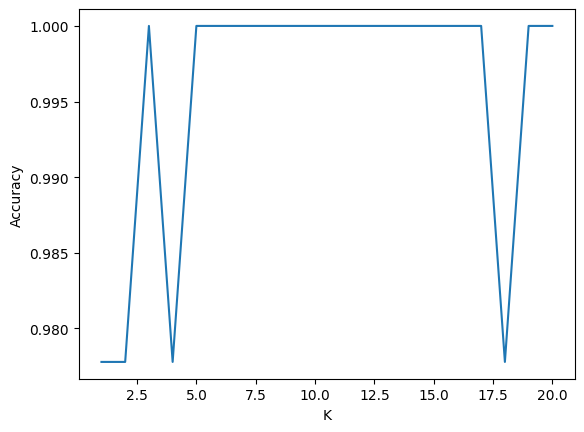

In [ ]:

k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()


## Hyperparameter Tuning with GridSearch

In [ ]:
# what are these parameters?
param_grid = {
    'n_neighbors': range(1, 21),
    'p': [1, 2],
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)
grid.best_params_


{'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}

## Model Evaluation using tuned parameters

In [ ]:

best_knn = grid.best_estimator_
y_pred_pg = best_knn.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_pg))
print(classification_report(y_test, y_pred_pg))


[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## Reflection

---


1. Discuss computational complexity of KNN.
2. Why is KNN unsuitable for very large datasets?